# Risk Analysis & P&L Visualization

Computes worst-case simultaneous unrealized loss and visualizes P&L over time for sizing capital in `THESIS.md`.

**Methodology**: For each hour in the backtest, mark every open position to market using actual hourly prices, sum their unrealized P&L, and track the worst moment.

**Supports three data sources:**
- `api` — candles from HL API (~7 months, `data/market/hyperliquid/candles`, `data/runs/backtest/optimized_4pair_hl`)
- `reservoir` — hourly candles aggregated from Hydromancer Reservoir 1s data (~8 months, `data/market/_reservoir_hourly/candles`, `data/runs/backtest/_reservoir_hourly`)
- `binance_2y` — Binance futures hourly candles and funding for the active five-coin universe over ~2 years (`data/market/binance_futures/2y/candles`, `data/runs/backtest/original_4pair_2y`)

Change `DATA_SOURCE` below to switch.


In [1]:
# ── Configuration ─────────────────────────────────────────────────
DATA_SOURCE = 'binance_2y'  # 'api', 'reservoir', or 'binance_2y'

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTIONAL = 50000

def find_repo_root():
    """Find the repo root by looking for pyproject.toml."""
    candidates = [Path('.').resolve(), Path('..').resolve(), Path('../..').resolve()]
    for p in candidates:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'hypemm').exists():
            return p
    raise FileNotFoundError('Cannot find repo root. Run from the project directory.')

REPO_ROOT = find_repo_root()

if DATA_SOURCE == 'api':
    REPORTS_DIR = REPO_ROOT / 'data' / 'runs' / 'backtest' / 'optimized_4pair_hl'
    CANDLES_DIR = REPO_ROOT / 'data' / 'market' / 'hyperliquid' / 'candles'
    COINS = ['BTC', 'ETH', 'SOL', 'AVAX', 'DOGE', 'LINK']
elif DATA_SOURCE == 'reservoir':
    REPORTS_DIR = REPO_ROOT / 'data' / 'runs' / 'backtest' / '_reservoir_hourly'
    CANDLES_DIR = REPO_ROOT / 'data' / 'market' / '_reservoir_hourly' / 'candles'
    COINS = ['BTC', 'ETH', 'SOL', 'AVAX', 'DOGE', 'LINK']
elif DATA_SOURCE == 'binance_2y':
    REPORTS_DIR = REPO_ROOT / 'data' / 'runs' / 'backtest' / 'original_4pair_2y'
    CANDLES_DIR = REPO_ROOT / 'data' / 'market' / 'binance_futures' / '2y' / 'candles'
    COINS = ['BTC', 'LINK', 'SOL', 'DOGE', 'AVAX']
else:
    raise ValueError(f'Unknown DATA_SOURCE: {DATA_SOURCE}')

print(f'Repo root: {REPO_ROOT}')
print(f'Using {DATA_SOURCE} data')
print(f'  Reports: {REPORTS_DIR}')
print(f'  Candles: {CANDLES_DIR}')
print(f'  Coins: {COINS}')

Repo root: /Users/thomas/My_Projects/metaverse/hypemm
Using binance_2y data
  Reports: /Users/thomas/My_Projects/metaverse/hypemm/data/runs/backtest/original_4pair_2y
  Candles: /Users/thomas/My_Projects/metaverse/hypemm/data/market/binance_futures/2y/candles
  Coins: ['BTC', 'LINK', 'SOL', 'DOGE', 'AVAX']


## Load data

In [2]:
# Load backtest trades
bt = pd.read_csv(REPORTS_DIR / 'backtest_trades.csv')
bt['entry_dt'] = pd.to_datetime(bt['entry_ts'], unit='ms', utc=True)
bt['exit_dt'] = pd.to_datetime(bt['exit_ts'], unit='ms', utc=True)

# Load filtered trades (correlation filter applied)
bt_filt = pd.read_csv(REPORTS_DIR / 'backtest_trades_filtered.csv')
bt_filt['entry_dt'] = pd.to_datetime(bt_filt['entry_ts'], unit='ms', utc=True)
bt_filt['exit_dt'] = pd.to_datetime(bt_filt['exit_ts'], unit='ms', utc=True)

# Load hourly candles for all coins
prices = {}
for coin in COINS:
    path = CANDLES_DIR / f'{coin}_1h.csv'
    if not path.exists():
        print(f'  Skipping {coin}: {path} not found')
        continue
    df = pd.read_csv(path)
    df['dt'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df = df.set_index('dt').sort_index()
    df = df[~df.index.duplicated(keep='first')]
    prices[coin] = df['close']

prices = pd.DataFrame(prices).ffill().dropna()
print('Loaded:')
print(f'  {len(bt)} unfiltered trades')
print(f'  {len(bt_filt)} filtered trades')
print(f'  {len(prices)} hourly price bars')
print(f'  Date range: {prices.index[0]} to {prices.index[-1]}')

Loaded:
  1595 unfiltered trades
  1353 filtered trades
  17520 hourly price bars
  Date range: 2024-04-21 18:00:00+00:00 to 2026-04-21 17:00:00+00:00


## P&L over time — cumulative equity curve

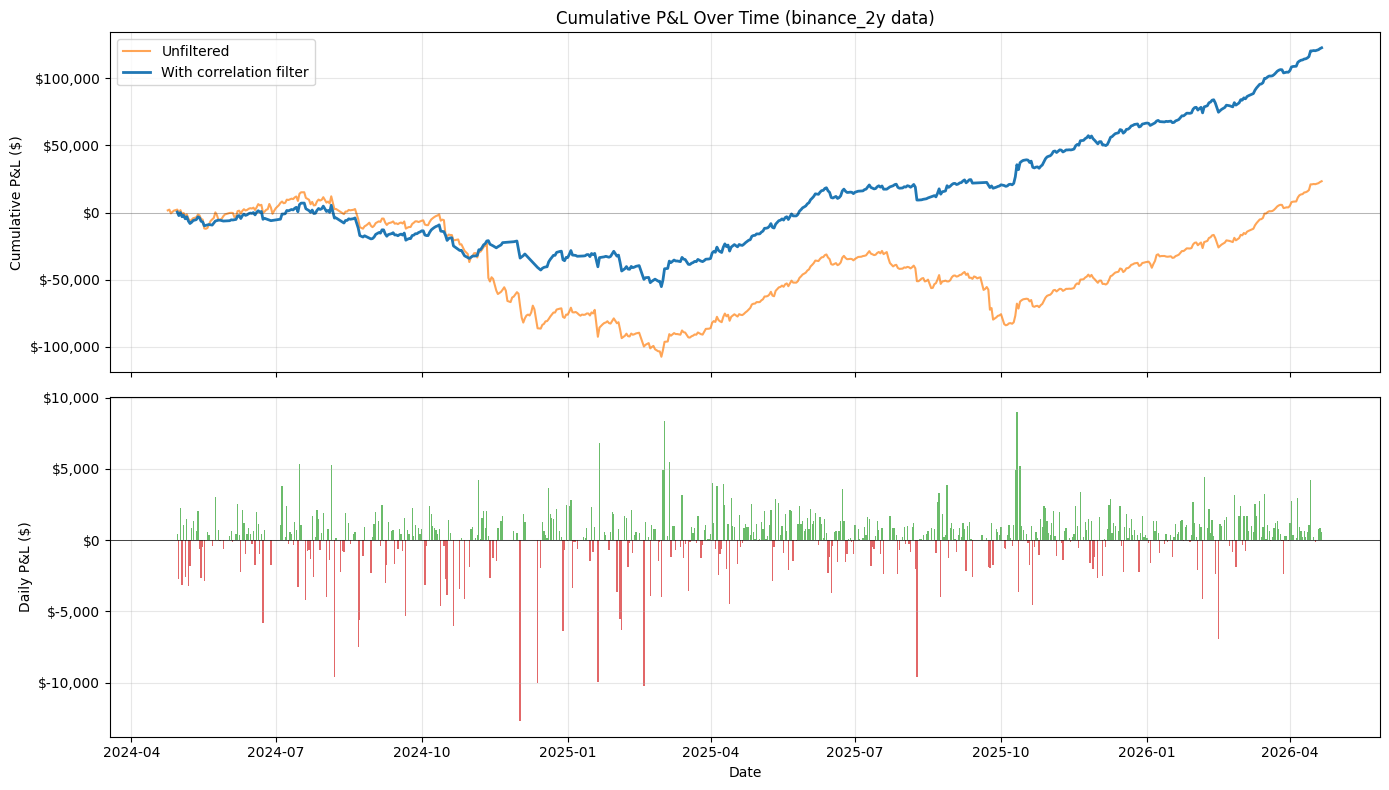


=== Unfiltered ===
  Final cumulative P&L: $+23,312
  Best day:  $+8,976 (2025-10-11)
  Worst day: $-25,967 (2024-11-12)
  Avg daily: $+35
  Positive days: 436/663 (66%)

=== With correlation filter ===
  Final cumulative P&L: $+122,658
  Best day:  $+8,976 (2025-10-11)
  Worst day: $-12,713 (2024-12-02)
  Avg daily: $+204
  Positive days: 407/601 (68%)


In [3]:
# Load daily equity from both unfiltered and filtered backtests
eq = pd.read_csv(REPORTS_DIR / 'daily_equity.csv')
eq['date'] = pd.to_datetime(eq['date'])

eq_filt = pd.read_csv(REPORTS_DIR / 'daily_equity_filtered.csv')
eq_filt['date'] = pd.to_datetime(eq_filt['date'])

# Plot cumulative P&L for both
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Cumulative equity curve
ax1 = axes[0]
ax1.plot(eq['date'], eq['cumulative_pnl'], label='Unfiltered', color='tab:orange', linewidth=1.5, alpha=0.7)
ax1.plot(eq_filt['date'], eq_filt['cumulative_pnl'], label='With correlation filter', color='tab:blue', linewidth=2)
ax1.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax1.set_ylabel('Cumulative P&L ($)')
ax1.set_title(f'Cumulative P&L Over Time ({DATA_SOURCE} data)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bottom: Daily P&L bars
ax2 = axes[1]
colors = ['tab:green' if v >= 0 else 'tab:red' for v in eq_filt['daily_pnl']]
ax2.bar(eq_filt['date'], eq_filt['daily_pnl'], color=colors, alpha=0.7, label='Daily P&L (filtered)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Daily P&L ($)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Summary stats
print('\n=== Unfiltered ===')
print(f'  Final cumulative P&L: ${eq["cumulative_pnl"].iloc[-1]:+,.0f}')
print(f'  Best day:  ${eq["daily_pnl"].max():+,.0f} ({eq.loc[eq["daily_pnl"].idxmax(), "date"].date()})')
print(f'  Worst day: ${eq["daily_pnl"].min():+,.0f} ({eq.loc[eq["daily_pnl"].idxmin(), "date"].date()})')
print(f'  Avg daily: ${eq["daily_pnl"].mean():+,.0f}')
print(f'  Positive days: {(eq["daily_pnl"]>0).sum()}/{len(eq)} ({(eq["daily_pnl"]>0).mean()*100:.0f}%)')

print('\n=== With correlation filter ===')
print(f'  Final cumulative P&L: ${eq_filt["cumulative_pnl"].iloc[-1]:+,.0f}')
print(f'  Best day:  ${eq_filt["daily_pnl"].max():+,.0f} ({eq_filt.loc[eq_filt["daily_pnl"].idxmax(), "date"].date()})')
print(f'  Worst day: ${eq_filt["daily_pnl"].min():+,.0f} ({eq_filt.loc[eq_filt["daily_pnl"].idxmin(), "date"].date()})')
print(f'  Avg daily: ${eq_filt["daily_pnl"].mean():+,.0f}')
print(f'  Positive days: {(eq_filt["daily_pnl"]>0).sum()}/{len(eq_filt)} ({(eq_filt["daily_pnl"]>0).mean()*100:.0f}%)')

## Drawdown visualization

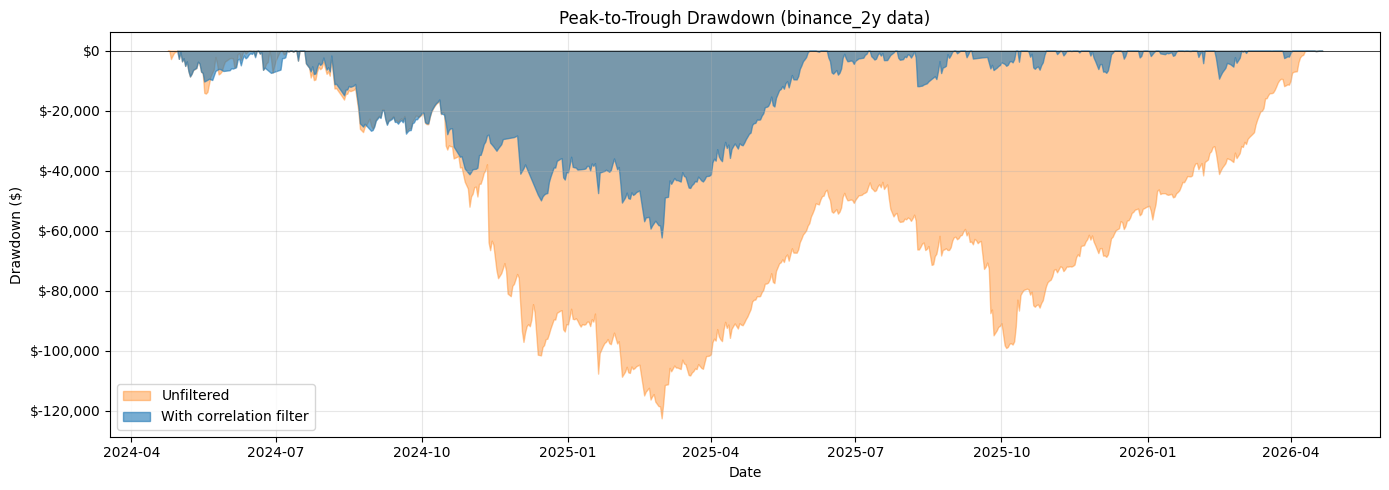

Unfiltered max drawdown: $-122,460
Filtered max drawdown:   $-62,207


In [4]:
# Compute rolling peak and drawdown
eq_filt['running_peak'] = eq_filt['cumulative_pnl'].cummax()
eq_filt['drawdown'] = eq_filt['cumulative_pnl'] - eq_filt['running_peak']

eq['running_peak'] = eq['cumulative_pnl'].cummax()
eq['drawdown'] = eq['cumulative_pnl'] - eq['running_peak']

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(eq['date'], eq['drawdown'], 0, color='tab:orange', alpha=0.4, label='Unfiltered')
ax.fill_between(eq_filt['date'], eq_filt['drawdown'], 0, color='tab:blue', alpha=0.6, label='With correlation filter')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Drawdown ($)')
ax.set_xlabel('Date')
ax.set_title(f'Peak-to-Trough Drawdown ({DATA_SOURCE} data)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'Unfiltered max drawdown: ${eq["drawdown"].min():,.0f}')
print(f'Filtered max drawdown:   ${eq_filt["drawdown"].min():,.0f}')

## Compute simultaneous unrealized P&L hour by hour

In [5]:
def position_unrealized(trade, current_a, current_b):
    """Unrealized P&L for a single position at current prices."""
    ea, eb = trade['entry_price_a'], trade['entry_price_b']
    if trade['direction'] == 'long_ratio':
        return NOTIONAL * (current_a - ea) / ea + NOTIONAL * (eb - current_b) / eb
    else:
        return NOTIONAL * (ea - current_a) / ea + NOTIONAL * (current_b - eb) / eb

def compute_concurrent_unrealized(trades_df, prices_df):
    """For each hour, compute actual simultaneous unrealized P&L across open positions."""
    rows = []
    for hour in prices_df.index:
        active = trades_df[(trades_df['entry_dt'] <= hour) & (trades_df['exit_dt'] > hour)]
        if len(active) == 0:
            rows.append({'hour': hour, 'n_positions': 0, 'unrealized': 0.0})
            continue

        total = 0.0
        for _, t in active.iterrows():
            coin_a, coin_b = t['pair'].split('/')
            if coin_a not in prices_df.columns or coin_b not in prices_df.columns:
                continue
            total += position_unrealized(t, prices_df.loc[hour, coin_a], prices_df.loc[hour, coin_b])

        rows.append({'hour': hour, 'n_positions': len(active), 'unrealized': total})
    return pd.DataFrame(rows)

print('Computing concurrent unrealized for unfiltered backtest...')
conc = compute_concurrent_unrealized(bt, prices)
print(f'  Done: {len(conc)} hours')

print('Computing concurrent unrealized for filtered backtest...')
conc_filt = compute_concurrent_unrealized(bt_filt, prices)
print(f'  Done: {len(conc_filt)} hours')

Computing concurrent unrealized for unfiltered backtest...


  Done: 17520 hours
Computing concurrent unrealized for filtered backtest...


  Done: 17520 hours


## Simultaneous unrealized over time

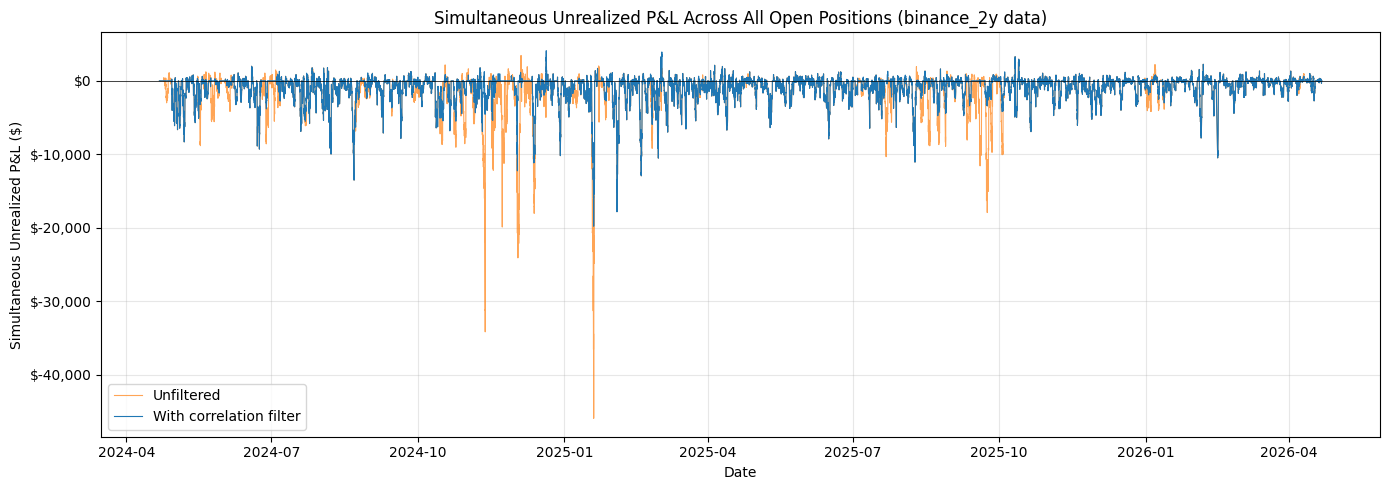

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(conc['hour'], conc['unrealized'], label='Unfiltered', color='tab:orange', linewidth=0.8, alpha=0.7)
ax.plot(conc_filt['hour'], conc_filt['unrealized'], label='With correlation filter', color='tab:blue', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.5)
if DATA_SOURCE in {'api', 'reservoir'}:
    ax.axhline(-19657, color='red', linestyle='--', linewidth=0.8, label='API worst ($-19,657)')
ax.set_ylabel('Simultaneous Unrealized P&L ($)')
ax.set_xlabel('Date')
ax.set_title(f'Simultaneous Unrealized P&L Across All Open Positions ({DATA_SOURCE} data)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


## Distribution summary

In [7]:
for label, c in [('Unfiltered', conc), ('Filtered', conc_filt)]:
    wp = c[c['n_positions'] > 0]
    print(f'=== {label} ({DATA_SOURCE}) ===')
    print(f'  Worst:    ${wp["unrealized"].min():+,.0f}')
    print(f'  5th %ile: ${wp["unrealized"].quantile(0.05):+,.0f}')
    print(f'  Median:   ${wp["unrealized"].median():+,.0f}')
    print(f'  95th %ile:${wp["unrealized"].quantile(0.95):+,.0f}')
    print(f'  Best:     ${wp["unrealized"].max():+,.0f}')
    print()
    print('  Time in concurrent positions:')
    for n in sorted(c['n_positions'].unique()):
        pct = (c['n_positions'] == n).sum() / len(c) * 100
        print(f'    {n} positions: {pct:.1f}% of hours')
    print()

=== Unfiltered (binance_2y) ===
  Worst:    $-45,966
  5th %ile: $-6,369
  Median:   $-826
  95th %ile:$+510
  Best:     $+3,451

  Time in concurrent positions:
    0 positions: 15.7% of hours
    1 positions: 27.7% of hours
    2 positions: 28.5% of hours
    3 positions: 21.6% of hours
    4 positions: 6.5% of hours

=== Filtered (binance_2y) ===
  Worst:    $-19,805
  5th %ile: $-4,795
  Median:   $-709
  95th %ile:$+489
  Best:     $+4,097

  Time in concurrent positions:
    0 positions: 24.3% of hours
    1 positions: 29.8% of hours
    2 positions: 26.1% of hours
    3 positions: 15.9% of hours
    4 positions: 3.9% of hours



## Worst moment — full breakdown (uses filtered trades)

In [8]:
# Use filtered backtest for the worst-moment analysis (this is what we'd actually trade)
worst_idx = conc_filt['unrealized'].idxmin()
worst_hour = conc_filt.loc[worst_idx, 'hour']
worst_total = conc_filt.loc[worst_idx, 'unrealized']

print(f'Worst moment (filtered): {worst_hour}')
print(f'Total simultaneous unrealized: ${worst_total:+,.0f}')
print()

print('Spot prices at that moment:')
for coin in COINS:
    if coin in prices.columns:
        print(f'  {coin:>6}: ${prices.loc[worst_hour, coin]:,.4f}')
print()

active = bt_filt[(bt_filt['entry_dt'] <= worst_hour) & (bt_filt['exit_dt'] > worst_hour)].copy()
active = active.sort_values('entry_dt')

for _, t in active.iterrows():
    coin_a, coin_b = t['pair'].split('/')
    cur_a = prices.loc[worst_hour, coin_a]
    cur_b = prices.loc[worst_hour, coin_b]
    ea, eb = t['entry_price_a'], t['entry_price_b']

    if t['direction'] == 'long_ratio':
        pnl_a = NOTIONAL * (cur_a - ea) / ea
        pnl_b = NOTIONAL * (eb - cur_b) / eb
        dir_desc = f'LONG {coin_a} / SHORT {coin_b}'
    else:
        pnl_a = NOTIONAL * (ea - cur_a) / ea
        pnl_b = NOTIONAL * (cur_b - eb) / eb
        dir_desc = f'SHORT {coin_a} / LONG {coin_b}'

    total = pnl_a + pnl_b
    hours_held = (worst_hour - t['entry_dt']).total_seconds() / 3600

    print(f'  {t["pair"]} — {dir_desc}')
    print(f'    Entry: {t["entry_dt"]} at z={t["entry_z"]:+.2f}')
    print(f'    Held: {hours_held:.0f}h (full hold: {t["hours_held"]}h, exit at {t["exit_dt"]})')
    print(f'    {coin_a}: ${ea:,.4f} → ${cur_a:,.4f} ({(cur_a-ea)/ea*100:+.2f}%) → leg P&L: ${pnl_a:+,.0f}')
    print(f'    {coin_b}: ${eb:,.4f} → ${cur_b:,.4f} ({(cur_b-eb)/eb*100:+.2f}%) → leg P&L: ${pnl_b:+,.0f}')
    print(f'    Position unrealized at worst: ${total:+,.0f}')
    print(f'    Final outcome: ${t["net_pnl"]:+,.0f} (exit z={t["exit_z"]:+.2f}, {t["exit_reason"]})')
    print()

Worst moment (filtered): 2025-01-19 11:00:00+00:00
Total simultaneous unrealized: $-19,805

Spot prices at that moment:
     BTC: $104,353.8000
    LINK: $22.3990
     SOL: $286.0900
    DOGE: $0.3629
    AVAX: $36.6430

  SOL/AVAX — SHORT SOL / LONG AVAX
    Entry: 2025-01-18 03:00:00+00:00 at z=+2.19
    Held: 32h (full hold: 45h, exit at 2025-01-20 00:00:00+00:00)
    SOL: $220.3200 → $286.0900 (+29.85%) → leg P&L: $-14,926
    AVAX: $40.6050 → $36.6430 (-9.76%) → leg P&L: $-4,879
    Position unrealized at worst: $-19,805
    Final outcome: $-11,088 (exit z=+0.48, mean_revert)



## Timeline around worst moment (±12 hours)

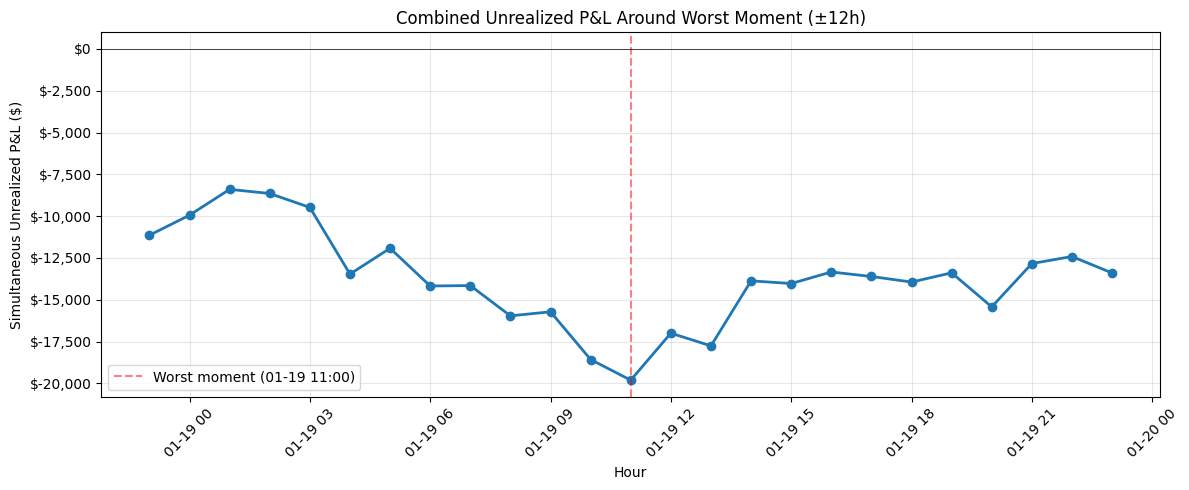

                Hour   N Pos      Unrealized
-------------------- ------- ---------------
    2025-01-18 23:00       1 $      -11,140
    2025-01-19 00:00       1 $       -9,941
    2025-01-19 01:00       1 $       -8,398
    2025-01-19 02:00       1 $       -8,645
    2025-01-19 03:00       1 $       -9,478
    2025-01-19 04:00       1 $      -13,463
    2025-01-19 05:00       1 $      -11,919
    2025-01-19 06:00       1 $      -14,174
    2025-01-19 07:00       1 $      -14,150
    2025-01-19 08:00       1 $      -15,960
    2025-01-19 09:00       1 $      -15,718
    2025-01-19 10:00       1 $      -18,571
    2025-01-19 11:00       1 $      -19,805  ← WORST
    2025-01-19 12:00       1 $      -16,993
    2025-01-19 13:00       1 $      -17,755
    2025-01-19 14:00       1 $      -13,868
    2025-01-19 15:00       1 $      -14,028
    2025-01-19 16:00       1 $      -13,338
    2025-01-19 17:00       1 $      -13,607
    2025-01-19 18:00       1 $      -13,940
    2025-01-19 19:00 

In [9]:
window_start = worst_hour - pd.Timedelta(hours=12)
window_end = worst_hour + pd.Timedelta(hours=12)
window = conc_filt[(conc_filt['hour'] >= window_start) & (conc_filt['hour'] <= window_end)].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(window['hour'], window['unrealized'], marker='o', color='tab:blue', linewidth=2)
ax.axvline(worst_hour, color='red', linestyle='--', alpha=0.5, label=f'Worst moment ({worst_hour.strftime("%m-%d %H:%M")})')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Simultaneous Unrealized P&L ($)')
ax.set_xlabel('Hour')
ax.set_title('Combined Unrealized P&L Around Worst Moment (±12h)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Table view
print(f'{"Hour":>20} {"N Pos":>7} {"Unrealized":>15}')
print(f'{"-"*20} {"-"*7} {"-"*15}')
for _, row in window.iterrows():
    marker = '  ← WORST' if row['hour'] == worst_hour else ''
    print(f'{row["hour"].strftime("%Y-%m-%d %H:%M"):>20} {row["n_positions"]:>7} ${row["unrealized"]:>+13,.0f}{marker}')

## Capital requirements by leverage

In [10]:
worst_case = abs(worst_total)
pair_count = bt_filt['pair'].nunique()
max_notional = pair_count * 2 * NOTIONAL

print(f'Active pairs: {pair_count}')
print(f'Max notional ({pair_count} pairs, 2 legs, ${NOTIONAL:,}/leg): ${max_notional:,}')
print(f'Worst-case simultaneous unrealized ({DATA_SOURCE}, filtered): ${worst_case:,.0f}')
print()
print(f'{"Leverage":>9} {"Margin":>10} {"Buffer":>10} {"Capital":>10} {"Cushion":>9} {"Verdict":>8}')
print('-' * 65)

for lev in [1, 2, 3, 5, 7, 10, 15, 20]:
    margin = max_notional / lev
    if lev <= 3:
        buffer = max(50000, worst_case * 2)
    elif lev <= 5:
        buffer = 40000
    else:
        buffer = 20000
    capital = margin + buffer
    cushion = buffer / worst_case
    verdict = '✅' if cushion >= 1.5 else '⚠️' if cushion >= 1.0 else '❌'
    print(f'{lev:>7}x  ${margin:>8,.0f} ${buffer:>8,.0f} ${capital:>8,.0f} {cushion:>7.1f}x {verdict:>8}')

print()
print('Cushion = buffer / worst-case simultaneous unrealized')


Active pairs: 4
Max notional (4 pairs, 2 legs, $50,000/leg): $400,000
Worst-case simultaneous unrealized (binance_2y, filtered): $19,805

 Leverage     Margin     Buffer    Capital   Cushion  Verdict
-----------------------------------------------------------------
      1x  $ 400,000 $  50,000 $ 450,000     2.5x        ✅
      2x  $ 200,000 $  50,000 $ 250,000     2.5x        ✅
      3x  $ 133,333 $  50,000 $ 183,333     2.5x        ✅
      5x  $  80,000 $  40,000 $ 120,000     2.0x        ✅
      7x  $  57,143 $  20,000 $  77,143     1.0x       ⚠️
     10x  $  40,000 $  20,000 $  60,000     1.0x       ⚠️
     15x  $  26,667 $  20,000 $  46,667     1.0x       ⚠️
     20x  $  20,000 $  20,000 $  40,000     1.0x       ⚠️

Cushion = buffer / worst-case simultaneous unrealized


## Worked example: $120K at 5x during the worst moment

In [11]:
capital = 120000
leverage = 5
margin = max_notional / leverage
maint_margin = margin / 2  # rough approximation

equity_at_worst = capital + worst_total  # worst_total is negative
headroom = equity_at_worst - maint_margin
loss_to_liquidation = capital - maint_margin

print('Setup:')
print(f'  Capital:              ${capital:,}')
print(f'  Leverage:             {leverage}x')
print(f'  Total notional:       ${max_notional:,}')
print(f'  Initial margin:       ${margin:,.0f}')
print(f'  Free buffer:          ${capital - margin:,.0f}')
print(f'  Maintenance margin:   ~${maint_margin:,.0f}')
print()
print(f'At worst moment (-${worst_case:,.0f} unrealized):')
print(f'  Account equity:       ${equity_at_worst:,.0f}')
print(f'  Distance to liquidation: ${headroom:,.0f}')
print(f'  % of headroom used:   {(worst_case / loss_to_liquidation) * 100:.0f}%')
print()
print('To actually liquidate:')
print(f'  Required loss:        ${loss_to_liquidation:,.0f}')
print(f'  Multiple of worst:    {loss_to_liquidation / worst_case:.1f}x'),

Setup:
  Capital:              $120,000
  Leverage:             5x
  Total notional:       $400,000
  Initial margin:       $80,000
  Free buffer:          $40,000
  Maintenance margin:   ~$40,000

At worst moment (-$19,805 unrealized):
  Account equity:       $100,195
  Distance to liquidation: $60,195
  % of headroom used:   25%

To actually liquidate:
  Required loss:        $80,000
  Multiple of worst:    4.0x


(None,)

## Liquidation Cushion Over Time

This section tracks a simple futures-style liquidation buffer through time for the filtered portfolio using full account equity, not just unrealized P&L.

Assumptions:
- Cross-margin style view of the whole portfolio
- Account capital is fixed at the chosen level below
- Realized P&L accumulates through time from closed trades
- Unrealized P&L comes from all currently open positions each hour
- Deployed notional changes with the number of open pairs each hour
- Maintenance margin is approximated as `50%` of initial margin, consistent with the worked example above

Metrics:
- `equity`: starting capital + realized cumulative P&L + current unrealized P&L
- `maintenance margin`: required margin based on currently deployed notional
- `margin ratio`: `equity / maintenance margin`; liquidation risk begins when this drops below `1.0`
- `buffer to liquidation`: `equity - maintenance margin`


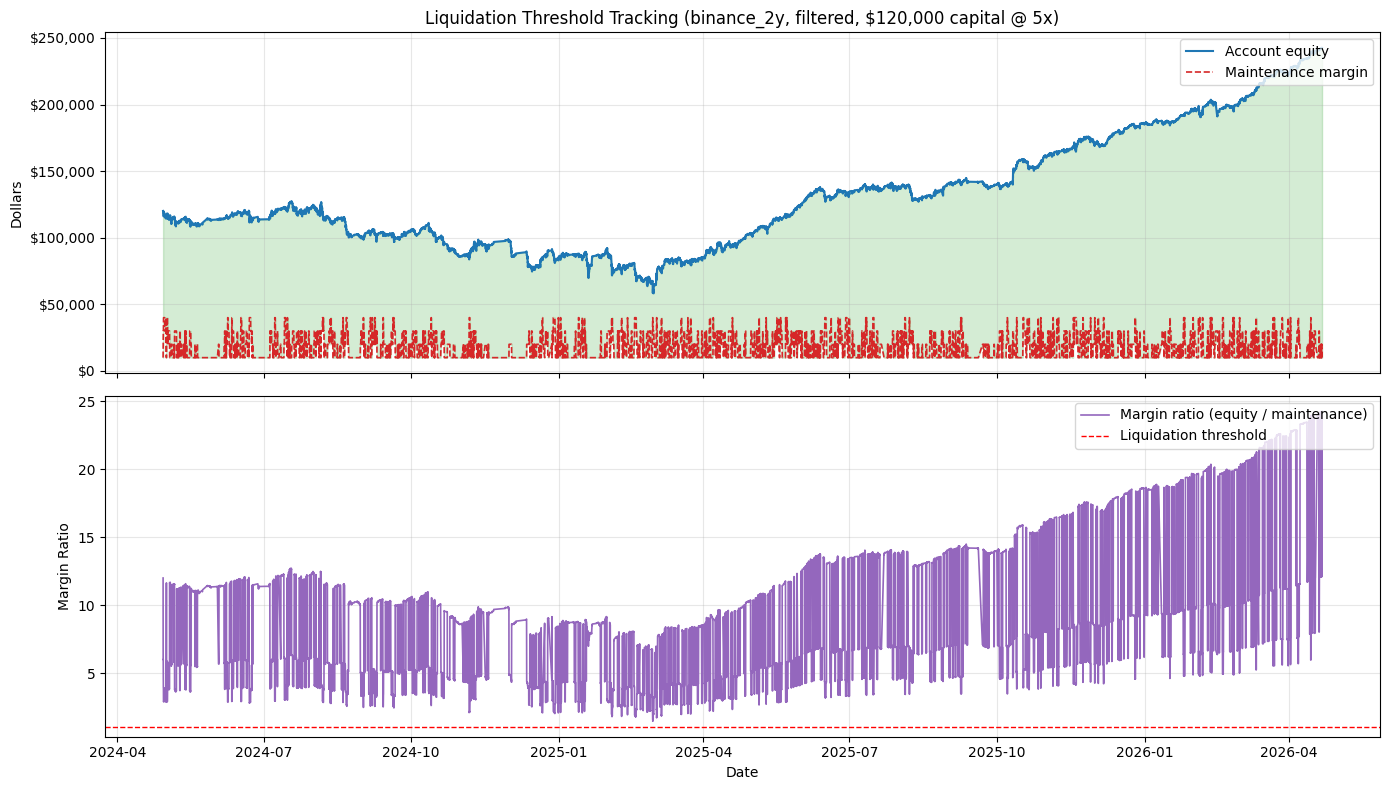

=== Liquidation Risk Summary ===
Assumed capital:            $120,000
Assumed leverage:           5x
Maintenance fraction:       50% of initial margin
Would liquidate:            False

Worst buffer to liquidation:
  Time:                     2025-02-28 14:00:00+00:00
  Open pairs:               4
  Realized cumulative P&L:  $-52,406
  Unrealized P&L:           $-9,159
  Equity:                   $58,434
  Maintenance margin:       $40,000
  Buffer to liquidation:    $18,434

Worst margin ratio:
  Time:                     2025-02-28 14:00:00+00:00
  Margin ratio:             1.46x
  Buffer as % of equity:    31.5%

Interpretation:
  Margin ratio > 1.0 means equity remains above maintenance margin.
  Buffer to liquidation > 0 means no liquidation under this simplified cross-margin model.


In [12]:
ACCOUNT_CAPITAL = 120_000
ACCOUNT_LEVERAGE = 5
MAINTENANCE_FRACTION = 0.50  # same approximation used in the worked example

liq = conc_filt.copy()
liq['hour'] = pd.to_datetime(liq['hour'], utc=True)

realized = bt_filt[['exit_dt', 'net_pnl']].copy().sort_values('exit_dt')
realized['realized_cumulative_pnl'] = realized['net_pnl'].cumsum()
liq = pd.merge_asof(
    liq.sort_values('hour'),
    realized[['exit_dt', 'realized_cumulative_pnl']].rename(columns={'exit_dt': 'hour'}),
    on='hour',
    direction='backward',
)
liq['realized_cumulative_pnl'] = liq['realized_cumulative_pnl'].fillna(0.0)
liq['deployed_notional'] = liq['n_positions'] * 2 * NOTIONAL
liq['initial_margin'] = liq['deployed_notional'] / ACCOUNT_LEVERAGE
liq['maintenance_margin'] = liq['initial_margin'] * MAINTENANCE_FRACTION
liq['equity'] = ACCOUNT_CAPITAL + liq['realized_cumulative_pnl'] + liq['unrealized']
liq['buffer_to_liq'] = liq['equity'] - liq['maintenance_margin']
liq['margin_ratio'] = np.where(
    liq['maintenance_margin'] > 0,
    liq['equity'] / liq['maintenance_margin'],
    np.nan,
)
liq['buffer_pct_of_equity'] = np.where(
    liq['equity'] != 0,
    liq['buffer_to_liq'] / liq['equity'],
    np.nan,
)

active_liq = liq[liq['n_positions'] > 0].copy()
worst_buffer_row = active_liq.loc[active_liq['buffer_to_liq'].idxmin()]
worst_ratio_row = active_liq.loc[active_liq['margin_ratio'].idxmin()]
would_liquidate = bool((active_liq['buffer_to_liq'] <= 0).any())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.plot(active_liq['hour'], active_liq['equity'], label='Account equity', color='tab:blue', linewidth=1.5)
ax1.plot(active_liq['hour'], active_liq['maintenance_margin'], label='Maintenance margin', color='tab:red', linestyle='--', linewidth=1.2)
ax1.fill_between(
    active_liq['hour'],
    active_liq['maintenance_margin'],
    active_liq['equity'],
    where=active_liq['equity'] >= active_liq['maintenance_margin'],
    color='tab:green',
    alpha=0.20,
)
ax1.set_ylabel('Dollars')
ax1.set_title(f'Liquidation Threshold Tracking ({DATA_SOURCE}, filtered, ${ACCOUNT_CAPITAL:,} capital @ {ACCOUNT_LEVERAGE}x)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = axes[1]
ax2.plot(active_liq['hour'], active_liq['margin_ratio'], color='tab:purple', linewidth=1.2, label='Margin ratio (equity / maintenance)')
ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.0, label='Liquidation threshold')
ax2.set_ylabel('Margin Ratio')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print('=== Liquidation Risk Summary ===')
print(f'Assumed capital:            ${ACCOUNT_CAPITAL:,.0f}')
print(f'Assumed leverage:           {ACCOUNT_LEVERAGE}x')
print(f'Maintenance fraction:       {MAINTENANCE_FRACTION:.0%} of initial margin')
print(f'Would liquidate:            {would_liquidate}')
print()
print('Worst buffer to liquidation:')
print(f"  Time:                     {worst_buffer_row['hour']}")
print(f"  Open pairs:               {int(worst_buffer_row['n_positions'])}")
print(f"  Realized cumulative P&L:  ${worst_buffer_row['realized_cumulative_pnl']:,.0f}")
print(f"  Unrealized P&L:           ${worst_buffer_row['unrealized']:,.0f}")
print(f"  Equity:                   ${worst_buffer_row['equity']:,.0f}")
print(f"  Maintenance margin:       ${worst_buffer_row['maintenance_margin']:,.0f}")
print(f"  Buffer to liquidation:    ${worst_buffer_row['buffer_to_liq']:,.0f}")
print()
print('Worst margin ratio:')
print(f"  Time:                     {worst_ratio_row['hour']}")
print(f"  Margin ratio:             {worst_ratio_row['margin_ratio']:.2f}x")
print(f"  Buffer as % of equity:    {worst_ratio_row['buffer_pct_of_equity']:.1%}")
print()
print('Interpretation:')
print('  Margin ratio > 1.0 means equity remains above maintenance margin.')
print('  Buffer to liquidation > 0 means no liquidation under this simplified cross-margin model.')


## All daily P&L values

In [13]:
# Show all daily P&L values for both unfiltered and filtered backtests

# Build comparison table
daily_comparison = eq_filt[['date', 'daily_pnl', 'cumulative_pnl', 'num_trades']].copy()
daily_comparison = daily_comparison.rename(columns={
    'daily_pnl': 'daily_pnl_filtered',
    'cumulative_pnl': 'cum_pnl_filtered',
    'num_trades': 'trades_filtered',
})

eq_uf = eq[['date', 'daily_pnl', 'cumulative_pnl', 'num_trades']].rename(columns={
    'daily_pnl': 'daily_pnl_unfiltered',
    'cumulative_pnl': 'cum_pnl_unfiltered',
    'num_trades': 'trades_unfiltered',
})

daily_table = pd.merge(daily_comparison, eq_uf, on='date', how='outer').sort_values('date').reset_index(drop=True)
daily_table = daily_table.fillna(0)
daily_table['date'] = daily_table['date'].dt.strftime('%Y-%m-%d')

# Order columns nicely
daily_table = daily_table[['date',
    'trades_filtered', 'daily_pnl_filtered', 'cum_pnl_filtered',
    'trades_unfiltered', 'daily_pnl_unfiltered', 'cum_pnl_unfiltered']]

print(f'Total days: {len(daily_table)}')
print()

# Show full table with pandas display options
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: f'${x:+,.0f}')

daily_table

Total days: 663



,date,trades_filtered,daily_pnl_filtered,cum_pnl_filtered,trades_unfiltered,daily_pnl_unfiltered,cum_pnl_unfiltered
0,2024-04-24,$+0,$+0,$+0,2,"$+1,620","$+1,620"
1,2024-04-25,$+0,$+0,$+0,1,$+562,"$+2,182"
2,2024-04-26,$+0,$+0,$+0,2,"$-2,787",$-606
3,2024-04-27,$+0,$+0,$+0,4,"$+1,131",$+525
4,2024-04-28,$+0,$+0,$+0,2,"$+1,002","$+1,527"
5,2024-04-29,$+0,$+0,$+0,1,$+266,"$+1,793"
6,2024-04-30,$+1,$+421,$+421,1,$+421,"$+2,214"
7,2024-05-01,$+5,"$-2,713","$-2,292",5,"$-2,713",$-499
8,2024-05-02,$+2,"$+2,284",$-8,2,"$+2,284","$+1,785"
9,2024-05-03,$+3,"$-3,119","$-3,127",3,"$-3,119","$-1,334"


## Regime-Filtered BTC/SOL Scenarios

These scenarios test whether `BTC/SOL` should be disabled or de-risked in macro regimes where it performed poorly in the 2-year Binance sample.

Scenarios:
- `skip_btcsol_bull90`: do not open new `BTC/SOL` trades when BTC 90-day return is greater than 20%
- `skip_btcsol_altslead`: do not open new `BTC/SOL` trades when the 30-day average alt return exceeds BTC's 30-day return enough to fall in the `alts_lead` bucket
- `btcsol_hold24_if_either`: keep trading `BTC/SOL`, but shorten max hold from 48h to 24h whenever either regime is active
- `skip_btcsol_either`: apply both entry filters together


In [14]:
import os
import sys

repo_root = REPO_ROOT  # from cell 1
src_root = repo_root / 'src'
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

os.chdir(repo_root)

from hypemm.backtest import summarize_backtest
from hypemm.config import load_config
from hypemm.data import load_candles
from hypemm.engine import _determine_exit_reason
from hypemm.funding import compute_funding_cost, load_funding
from hypemm.math import compute_leg_pnl, compute_log_ratios, compute_z_scores, rolling_correlation
from hypemm.models import CompletedTrade, Direction, ExitReason

cfg = load_config(repo_root / 'configs' / 'backtest' / 'original_4pair_2y.toml')
strategy = cfg.strategy
scenario_candles_dir = repo_root / cfg.infra.candles_dir
scenario_funding_dir = repo_root / cfg.infra.funding_dir
scenario_reports_dir = repo_root / cfg.infra.reports_dir
scenario_prices = load_candles(scenario_candles_dir, strategy.all_coins)
scenario_funding = load_funding(scenario_funding_dir, strategy.all_coins)
scenario_bt = pd.read_csv(scenario_reports_dir / 'backtest_trades_filtered.csv')

print(f'Loaded {len(scenario_prices)} hourly bars')
print(f'Period: {scenario_prices.index[0].date()} → {scenario_prices.index[-1].date()}')
print(f'Pairs: {[p.label for p in strategy.pairs]}')

# BTC price series for regime analysis
btc_raw = pd.read_csv(scenario_candles_dir / 'BTC_1h.csv')
btc_raw['dt'] = pd.to_datetime(btc_raw['timestamp'], unit='ms', utc=True)
btc_raw['close'] = btc_raw['close'].astype(float)
btc_df = btc_raw[['dt', 'close']].copy()
btc_df = btc_df.set_index('dt').sort_index()

regimes = pd.DataFrame(index=btc_df.index)
regimes['bull_90d'] = btc_df['close'] / btc_df['close'].shift(24 * 90) - 1 > 0.20

scenario_px = {}
for coin in strategy.all_coins:
    raw = pd.read_csv(scenario_candles_dir / f'{coin}_1h.csv')
    raw['dt'] = pd.to_datetime(raw['timestamp'], unit='ms', utc=True)
    scenario_px[coin] = raw.set_index('dt')['close'].astype(float)

scenario_px = pd.DataFrame(scenario_px)
scenario_ret30 = scenario_px / scenario_px.shift(24 * 30) - 1
regimes['alt_mean_ret_30d'] = scenario_ret30[['SOL', 'LINK', 'DOGE', 'AVAX']].mean(axis=1)
regimes['btc_minus_alt_30d'] = scenario_ret30['BTC'] - regimes['alt_mean_ret_30d']
q1 = regimes['btc_minus_alt_30d'].quantile(0.33)
q2 = regimes['btc_minus_alt_30d'].quantile(0.66)
regimes['alts_lead'] = pd.cut(
    regimes['btc_minus_alt_30d'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['alts_lead', 'mixed', 'btc_leads'],
) == 'alts_lead'

btcsol_pair = next(pair for pair in strategy.pairs if pair.label == 'BTC/SOL')
btc_prices = scenario_prices[btcsol_pair.coin_a].values
sol_prices = scenario_prices[btcsol_pair.coin_b].values
timestamps = scenario_prices.index

btcsol_log_ratios = compute_log_ratios(btc_prices, sol_prices)
btcsol_z = compute_z_scores(btcsol_log_ratios, strategy.lookback_hours)
btcsol_corr = np.concatenate([
    [np.nan],
    rolling_correlation(
        np.diff(np.log(btc_prices)),
        np.diff(np.log(sol_prices)),
        strategy.corr_window_hours,
    ),
])

# --- BTC/SOL scenario simulation functions ---

def rows_to_trades(df):
    trades = []
    for _, row in df.iterrows():
        d = Direction.LONG_RATIO if row['direction'] == 'long_ratio' else Direction.SHORT_RATIO
        reason = ExitReason(row['exit_reason'])
        trades.append(CompletedTrade(
            pair_label=row['pair'], direction=d,
            entry_ts=int(row['entry_ts']), exit_ts=int(row['exit_ts']),
            entry_z=float(row['entry_z']), exit_z=float(row['exit_z']),
            hours_held=int(row['hours_held']),
            entry_price_a=float(row['entry_price_a']), entry_price_b=float(row['entry_price_b']),
            exit_price_a=float(row['exit_price_a']), exit_price_b=float(row['exit_price_b']),
            pnl_leg_a=float(row['pnl_leg_a']), pnl_leg_b=float(row['pnl_leg_b']),
            gross_pnl=float(row['gross_pnl']), cost=float(row['cost']),
            net_pnl=float(row['net_pnl']), exit_reason=reason,
            entry_correlation=float(row.get('entry_correlation', 0)),
            funding_cost=float(row.get('funding_cost', 0)),
            max_adverse_excursion=float(row.get('max_adverse_excursion', 0)),
        ))
    return trades


def run_btcsol_variant(skip_bull=False, skip_alts=False, shorten_hold=False, short_hold_hours=24):
    n = len(btc_prices)
    position = None
    cooldown = 0
    completed = []

    for i in range(strategy.lookback_hours + 1, n):
        z = btcsol_z[i]
        if np.isnan(z):
            continue
        corr = btcsol_corr[i] if not np.isnan(btcsol_corr[i]) else None
        ts = timestamps[i]
        ts_ms = int(ts.timestamp() * 1000)
        bull = bool(regimes['bull_90d'].reindex([ts]).iloc[0]) if ts in regimes.index else False
        alts = bool(regimes['alts_lead'].reindex([ts]).iloc[0]) if ts in regimes.index else False

        if position is None:
            if cooldown > 0:
                cooldown -= 1
                continue
            if corr is None or corr < strategy.corr_threshold:
                continue
            if skip_bull and bull:
                continue
            if skip_alts and alts:
                continue

            direction = None
            if z > strategy.entry_z:
                direction = Direction.SHORT_RATIO
            elif z < -strategy.entry_z:
                direction = Direction.LONG_RATIO
            if direction is None:
                continue

            max_hold = short_hold_hours if shorten_hold and (bull or alts) else strategy.max_hold_hours
            position = {
                'direction': direction, 'entry_z': z, 'hours_held': 0,
                'entry_price_a': float(btc_prices[i]),
                'entry_price_b': float(sol_prices[i]),
                'entry_time_ms': ts_ms, 'max_hold_hours': max_hold,
            }
            continue

        position['hours_held'] += 1
        reason = _determine_exit_reason(
            z, position['direction'], int(position['hours_held']),
            strategy.exit_z, strategy.stop_loss_z, int(position['max_hold_hours']),
        )
        if reason is None:
            continue

        pnl_a, pnl_b = compute_leg_pnl(
            position['direction'], strategy.notional_per_leg,
            position['entry_price_a'], position['entry_price_b'],
            float(btc_prices[i]), float(sol_prices[i]),
        )
        gross = pnl_a + pnl_b
        net = gross - strategy.round_trip_cost
        funding_cost = compute_funding_cost(
            position['direction'], strategy.notional_per_leg,
            position['entry_time_ms'], ts_ms,
            scenario_funding[btcsol_pair.coin_a],
            scenario_funding[btcsol_pair.coin_b],
        )
        net -= funding_cost

        completed.append(CompletedTrade(
            pair_label='BTC/SOL', direction=position['direction'],
            entry_ts=position['entry_time_ms'], exit_ts=ts_ms,
            entry_z=position['entry_z'], exit_z=float(z),
            hours_held=int(position['hours_held']),
            entry_price_a=position['entry_price_a'],
            entry_price_b=position['entry_price_b'],
            exit_price_a=float(btc_prices[i]),
            exit_price_b=float(sol_prices[i]),
            pnl_leg_a=pnl_a, pnl_leg_b=pnl_b,
            gross_pnl=gross, cost=strategy.round_trip_cost,
            net_pnl=net, exit_reason=reason,
            entry_correlation=0.0, funding_cost=funding_cost,
        ))
        position = None
        cooldown = strategy.cooldown_hours

    return completed

other_pair_trades = rows_to_trades(scenario_bt[scenario_bt['pair'] != 'BTC/SOL'])
baseline_btcsol = rows_to_trades(scenario_bt[scenario_bt['pair'] == 'BTC/SOL'])

scenario_variants = {
    'baseline': other_pair_trades + baseline_btcsol,
    'skip_btcsol_bull90': other_pair_trades + run_btcsol_variant(skip_bull=True),
    'skip_btcsol_altslead': other_pair_trades + run_btcsol_variant(skip_alts=True),
    'skip_btcsol_either': other_pair_trades + run_btcsol_variant(skip_bull=True, skip_alts=True),
    'btcsol_hold24_if_either': other_pair_trades + run_btcsol_variant(shorten_hold=True, short_hold_hours=24),
}

scenario_rows = []
for name, trades in scenario_variants.items():
    summary = summarize_backtest(trades, scenario_prices)
    btcsol_net = sum(t.net_pnl for t in trades if t.pair_label == 'BTC/SOL')
    scenario_rows.append({
        'scenario': name, 'trades': len(trades),
        'net_pnl': summary.total_net, 'win_rate': summary.win_rate,
        'sharpe': summary.sharpe, 'max_drawdown': summary.max_drawdown,
        'btcsol_net': btcsol_net,
    })

scenario_table = pd.DataFrame(scenario_rows).sort_values('sharpe', ascending=False).reset_index(drop=True)
scenario_table['net_vs_baseline'] = scenario_table['net_pnl'] - scenario_table.loc[scenario_table['scenario'] == 'baseline', 'net_pnl'].iloc[0]
scenario_table['dd_vs_baseline'] = scenario_table['max_drawdown'] - scenario_table.loc[scenario_table['scenario'] == 'baseline', 'max_drawdown'].iloc[0]
scenario_table = scenario_table[[
    'scenario', 'trades', 'net_pnl', 'net_vs_baseline', 'win_rate', 'sharpe',
    'max_drawdown', 'dd_vs_baseline', 'btcsol_net'
]]
scenario_table.style.format({
    'net_pnl': '${:,.0f}', 'net_vs_baseline': '${:+,.0f}',
    'win_rate': '{:.1f}%', 'sharpe': '{:.2f}',
    'max_drawdown': '${:,.0f}', 'dd_vs_baseline': '${:+,.0f}',
    'btcsol_net': '${:+,.0f}',
})

Loaded 17520 hourly bars
Period: 2024-04-21 → 2026-04-21
Pairs: ['LINK/SOL', 'DOGE/AVAX', 'SOL/AVAX', 'BTC/SOL']


,scenario,trades,net_pnl,net_vs_baseline,win_rate,sharpe,max_drawdown,dd_vs_baseline,btcsol_net
0,skip_btcsol_either,1241,"$154,291","$+31,634",71.9%,2.48,"$48,384","$-13,823","$+13,223"
1,skip_btcsol_altslead,1276,"$141,942","$+19,284",71.5%,2.25,"$56,017","$-6,190",$+873
2,skip_btcsol_bull90,1298,"$140,204","$+17,546",71.4%,2.17,"$50,917","$-11,290",$-865
3,btcsol_hold24_if_either,1372,"$133,228","$+10,570",70.3%,2.05,"$52,746","$-9,461","$-7,841"
4,baseline,1353,"$122,658",$+0,70.8%,1.84,"$62,207",$+0,"$-18,411"


## Scenario Equity Curves

This chart compares cumulative realized P&L across the baseline and all BTC/SOL regime-management variants on the same axis.


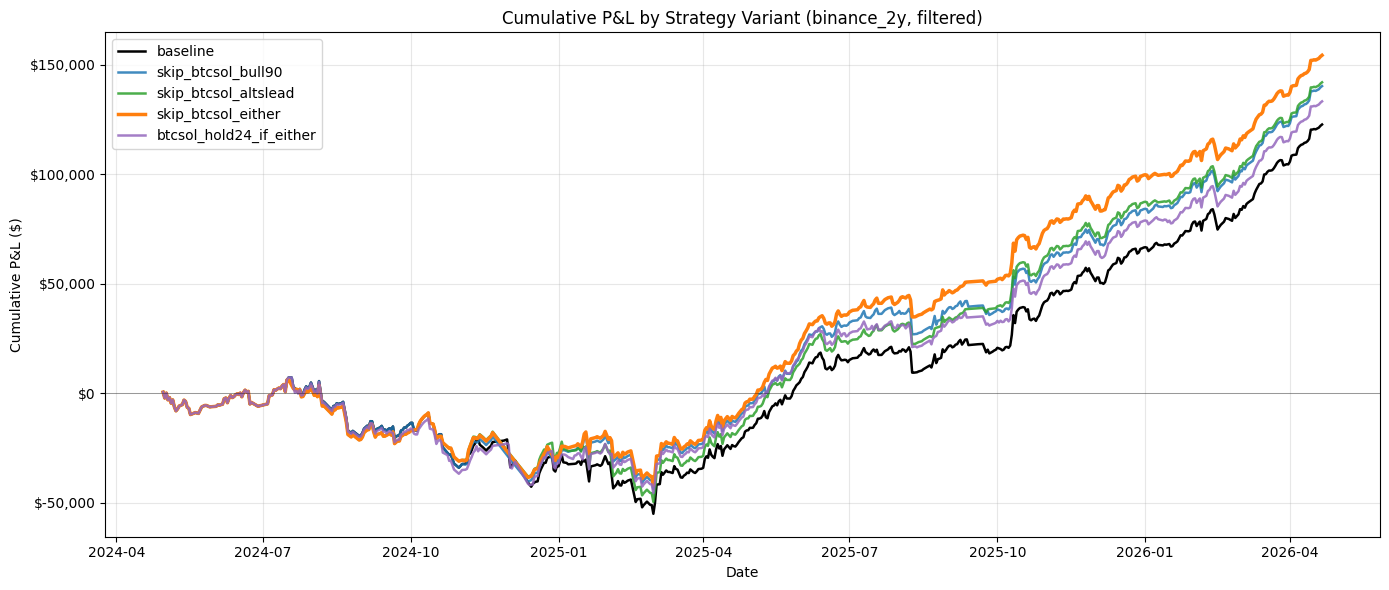

,scenario,final_pnl,best_day,worst_day
3,skip_btcsol_either,"$154,291","$8,976","$-10,478"
2,skip_btcsol_altslead,"$141,942","$8,976","$-10,478"
1,skip_btcsol_bull90,"$140,204","$8,976","$-10,478"
4,btcsol_hold24_if_either,"$133,228","$8,976","$-10,478"
0,baseline,"$122,658","$8,976","$-12,713"


In [15]:
def scenario_daily_equity(trades):
    df = pd.DataFrame([
        {
            'exit_dt': pd.to_datetime(t.exit_ts, unit='ms', utc=True),
            'net_pnl': t.net_pnl,
        }
        for t in trades
    ])
    if df.empty:
        return pd.DataFrame(columns=['date', 'daily_pnl', 'cumulative_pnl'])

    df['date'] = df['exit_dt'].dt.floor('D')
    daily = df.groupby('date', as_index=False)['net_pnl'].sum().rename(columns={'net_pnl': 'daily_pnl'})
    daily['cumulative_pnl'] = daily['daily_pnl'].cumsum()
    return daily

scenario_equity = {
    name: scenario_daily_equity(trades)
    for name, trades in scenario_variants.items()
}

fig, ax = plt.subplots(figsize=(14, 6))
colors = {
    'baseline': 'black',
    'skip_btcsol_bull90': 'tab:blue',
    'skip_btcsol_altslead': 'tab:green',
    'skip_btcsol_either': 'tab:orange',
    'btcsol_hold24_if_either': 'tab:purple',
}

for name, eq_curve in scenario_equity.items():
    if eq_curve.empty:
        continue
    linewidth = 2.5 if name == 'skip_btcsol_either' else 1.8
    alpha = 1.0 if name in {'baseline', 'skip_btcsol_either'} else 0.85
    ax.plot(
        eq_curve['date'],
        eq_curve['cumulative_pnl'],
        label=name,
        color=colors.get(name),
        linewidth=linewidth,
        alpha=alpha,
    )

ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
ax.set_title(f'Cumulative P&L by Strategy Variant ({DATA_SOURCE}, filtered)')
ax.set_ylabel('Cumulative P&L ($)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

scenario_curve_summary = pd.DataFrame([
    {
        'scenario': name,
        'final_pnl': eq_curve['cumulative_pnl'].iloc[-1] if not eq_curve.empty else 0.0,
        'best_day': eq_curve['daily_pnl'].max() if not eq_curve.empty else 0.0,
        'worst_day': eq_curve['daily_pnl'].min() if not eq_curve.empty else 0.0,
    }
    for name, eq_curve in scenario_equity.items()
]).sort_values('final_pnl', ascending=False)

scenario_curve_summary.style.format({
    'final_pnl': '${:,.0f}',
    'best_day': '${:,.0f}',
    'worst_day': '${:,.0f}',
})


## Progress-Exit Research

This section tests a more robust exit design on the stronger three-pair universe (`LINK/SOL`, `DOGE/AVAX`, `SOL/AVAX`).

Idea:
- keep the mean-reversion thesis
- but exit early if a trade is still not making enough progress back toward zero after a fixed number of hours

Promising variants from the 2-year sample:
- `entry25_baseline`: remove `BTC/SOL`, raise entry threshold to `2.5`
- `progress_h12_i10_z2.5`: after `12h`, require at least `10%` improvement in absolute z-score
- `progress_h24_i15_z2.5`: after `24h`, require at least `15%` improvement in absolute z-score


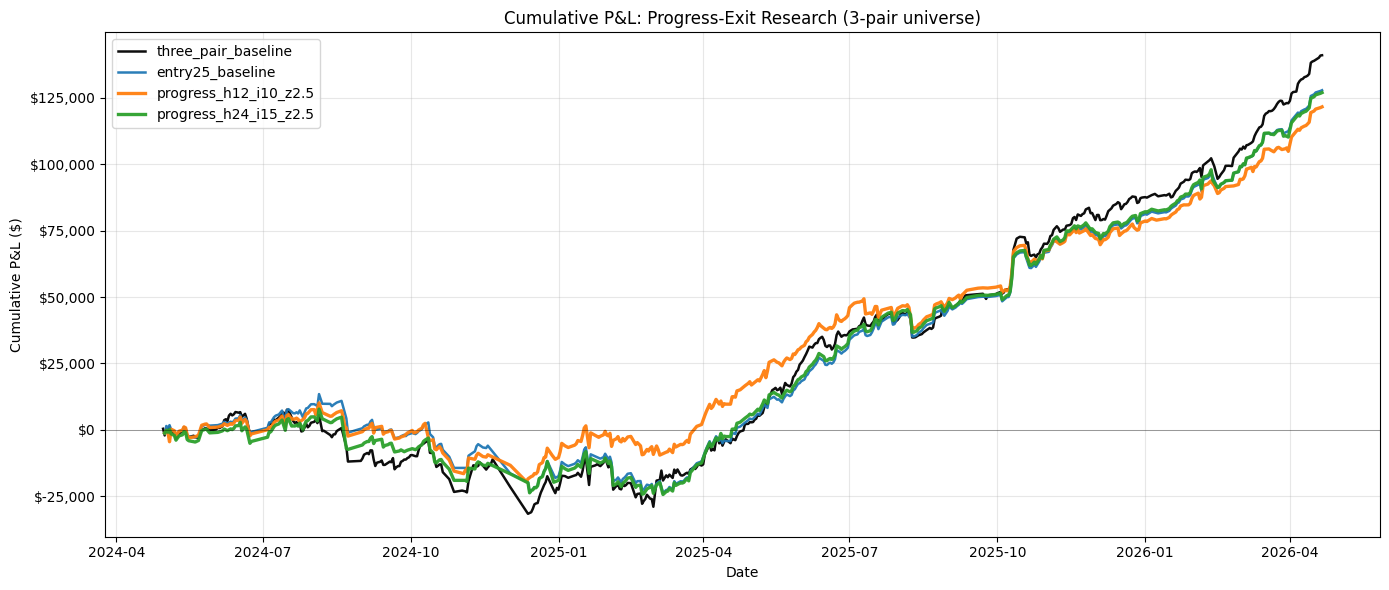

In [16]:
from dataclasses import replace

three_pair_strategy = replace(
    strategy,
    pairs=tuple(pair for pair in strategy.pairs if pair.label != 'BTC/SOL'),
)


def longest_recovery_days(trades):
    if not trades:
        return 0
    daily = {}
    for t in trades:
        day = pd.to_datetime(t.exit_ts, unit='ms', utc=True).floor('D')
        daily[day] = daily.get(day, 0.0) + t.net_pnl
    eq = pd.DataFrame({
        'date': sorted(daily),
        'daily_pnl': [daily[d] for d in sorted(daily)],
    })
    eq['cumulative_pnl'] = eq['daily_pnl'].cumsum()

    best = 0
    peak_val = float('-inf')
    peak_date = None
    for _, row in eq.iterrows():
        value = float(row['cumulative_pnl'])
        date = row['date']
        if value >= peak_val:
            peak_val = value
            peak_date = date
            continue
        recovery = eq[(eq['date'] >= date) & (eq['cumulative_pnl'] >= peak_val)]
        if not recovery.empty and peak_date is not None:
            best = max(best, int((recovery.iloc[0]['date'] - peak_date).days))
    return best


def run_progress_pair(pair, config, progress_hours=None, progress_improve=None):
    pa = scenario_prices[pair.coin_a].values
    pb = scenario_prices[pair.coin_b].values
    timestamps = scenario_prices.index
    z_scores = compute_z_scores(
        compute_log_ratios(np.asarray(pa), np.asarray(pb)),
        config.lookback_hours,
    )
    corr_values = np.concatenate([
        [np.nan],
        rolling_correlation(
            np.diff(np.log(pa)),
            np.diff(np.log(pb)),
            config.corr_window_hours,
        ),
    ])
    funding_a = scenario_funding[pair.coin_a]
    funding_b = scenario_funding[pair.coin_b]

    cooldown = 0
    position = None
    completed = []

    for i in range(config.lookback_hours + 2, len(pa)):
        z = z_scores[i]
        if np.isnan(z):
            continue

        corr = corr_values[i] if not np.isnan(corr_values[i]) else None
        ts_ms = int(timestamps[i].timestamp() * 1000)

        if position is None:
            if cooldown > 0:
                cooldown -= 1
                continue
            if corr is None or corr < config.corr_threshold:
                continue

            direction = None
            if z > config.entry_z:
                direction = Direction.SHORT_RATIO
            elif z < -config.entry_z:
                direction = Direction.LONG_RATIO
            if direction is None:
                continue

            position = {
                'direction': direction,
                'entry_z': float(z),
                'entry_price_a': float(pa[i]),
                'entry_price_b': float(pb[i]),
                'entry_time_ms': ts_ms,
                'entry_correlation': float(corr),
                'hours_held': 0,
            }
            continue

        position['hours_held'] += 1
        reason = _determine_exit_reason(
            float(z),
            position['direction'],
            int(position['hours_held']),
            config.exit_z,
            config.stop_loss_z,
            config.max_hold_hours,
        )

        if reason is None and progress_hours is not None and progress_improve is not None:
            if position['hours_held'] >= progress_hours:
                required_abs = abs(position['entry_z']) * (1.0 - progress_improve)
                if abs(z) > required_abs:
                    reason = ExitReason.TIME_STOP

        if reason is None:
            continue

        pnl_a, pnl_b = compute_leg_pnl(
            position['direction'],
            config.notional_per_leg,
            position['entry_price_a'],
            position['entry_price_b'],
            float(pa[i]),
            float(pb[i]),
        )
        gross = pnl_a + pnl_b
        funding_cost = compute_funding_cost(
            position['direction'],
            config.notional_per_leg,
            position['entry_time_ms'],
            ts_ms,
            funding_a,
            funding_b,
        )
        completed.append(
            CompletedTrade(
                pair_label=pair.label,
                direction=position['direction'],
                entry_ts=position['entry_time_ms'],
                exit_ts=ts_ms,
                entry_z=position['entry_z'],
                exit_z=float(z),
                hours_held=int(position['hours_held']),
                entry_price_a=position['entry_price_a'],
                entry_price_b=position['entry_price_b'],
                exit_price_a=float(pa[i]),
                exit_price_b=float(pb[i]),
                pnl_leg_a=pnl_a,
                pnl_leg_b=pnl_b,
                gross_pnl=gross,
                cost=config.round_trip_cost,
                net_pnl=gross - config.round_trip_cost - funding_cost,
                exit_reason=reason,
                entry_correlation=position['entry_correlation'],
                funding_cost=funding_cost,
                max_adverse_excursion=0.0,
            )
        )
        position = None
        cooldown = config.cooldown_hours

    return completed


def run_progress_all(config, progress_hours=None, progress_improve=None):
    trades = []
    for pair in config.pairs:
        trades.extend(run_progress_pair(pair, config, progress_hours=progress_hours, progress_improve=progress_improve))
    return trades

progress_variants = {
    'three_pair_baseline': run_progress_all(three_pair_strategy),
    'entry25_baseline': run_progress_all(replace(three_pair_strategy, entry_z=2.5)),
    'progress_h12_i10_z2.5': run_progress_all(replace(three_pair_strategy, entry_z=2.5), progress_hours=12, progress_improve=0.10),
    'progress_h24_i15_z2.5': run_progress_all(replace(three_pair_strategy, entry_z=2.5), progress_hours=24, progress_improve=0.15),
}

progress_rows = []
for name, trades in progress_variants.items():
    summary = summarize_backtest(trades, scenario_prices)
    progress_rows.append({
        'variant': name,
        'trades': len(trades),
        'net_pnl': summary.total_net,
        'win_rate': summary.win_rate,
        'sharpe': summary.sharpe,
        'max_drawdown': summary.max_drawdown,
        'recovery_days': longest_recovery_days(trades),
    })

progress_table = pd.DataFrame(progress_rows).sort_values(['sharpe', 'net_pnl'], ascending=[False, False]).reset_index(drop=True)
progress_table.style.format({
    'net_pnl': '${:,.0f}',
    'win_rate': '{:.1f}%',
    'sharpe': '{:.2f}',
    'max_drawdown': '${:,.0f}',
    'recovery_days': '{:.0f}',
})


def progress_daily_equity(trades):
    df = pd.DataFrame([
        {'exit_dt': pd.to_datetime(t.exit_ts, unit='ms', utc=True), 'net_pnl': t.net_pnl}
        for t in trades
    ])
    if df.empty:
        return pd.DataFrame(columns=['date', 'daily_pnl', 'cumulative_pnl'])
    df['date'] = df['exit_dt'].dt.floor('D')
    daily = df.groupby('date', as_index=False)['net_pnl'].sum().rename(columns={'net_pnl': 'daily_pnl'})
    daily['cumulative_pnl'] = daily['daily_pnl'].cumsum()
    return daily

progress_equity = {
    name: progress_daily_equity(trades)
    for name, trades in progress_variants.items()
}

fig, ax = plt.subplots(figsize=(14, 6))
progress_colors = {
    'three_pair_baseline': 'black',
    'entry25_baseline': 'tab:blue',
    'progress_h12_i10_z2.5': 'tab:orange',
    'progress_h24_i15_z2.5': 'tab:green',
}
for name, eq_curve in progress_equity.items():
    if eq_curve.empty:
        continue
    ax.plot(
        eq_curve['date'],
        eq_curve['cumulative_pnl'],
        label=name,
        color=progress_colors.get(name),
        linewidth=2.4 if 'progress' in name else 1.8,
        alpha=0.95,
    )

ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
ax.set_title('Cumulative P&L: Progress-Exit Research (3-pair universe)')
ax.set_ylabel('Cumulative P&L ($)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


## Walk-Forward Optimized Strategy — 2-Year Comparison

The walk-forward analysis on 6 years of data identified an optimized configuration:
- **3 pairs** (drop BTC/SOL)
- **entry_z = 2.5** (higher conviction entries)
- **max_hold = 36h** (cut dying trades 12h earlier)
- **progress-exit 12h/10%** (exit if z hasn't improved after 12 hours)

This section runs it on the same 2-year Binance dataset used above and compares against
the baseline, regime-filtered, and progress-exit variants already in this notebook.

In [17]:
from datetime import datetime, timezone

from hypemm.backtest import run_backtest_all_pairs
from hypemm.walkforward import (
    conditional_var,
    deflated_sharpe_ratio,
    probabilistic_sharpe_ratio,
    sortino_ratio,
)

# Build all strategy variants for comparison
optimized_config = replace(
    three_pair_strategy,
    entry_z=2.5,
    max_hold_hours=36,
    progress_exit_hours=12,
    progress_exit_pct=0.10,
)

optimized_hurst_config = replace(
    optimized_config,
    hurst_threshold=0.55,
)

# Run the optimized variants through the full backtest engine
# (uses the same 2-year Binance data already loaded)
print('Running optimized strategy on 2-year data...')
optimized_trades = run_backtest_all_pairs(scenario_prices, optimized_config, funding=scenario_funding)
print(f'  Optimized: {len(optimized_trades)} trades')

optimized_hurst_trades = run_backtest_all_pairs(scenario_prices, optimized_hurst_config, funding=scenario_funding)
print(f'  Optimized+Hurst: {len(optimized_hurst_trades)} trades')

# Also run: entry 2.5 only, and 3-pair baseline for clean comparison
entry25_config = replace(three_pair_strategy, entry_z=2.5)
entry25_trades = run_backtest_all_pairs(scenario_prices, entry25_config, funding=scenario_funding)
print(f'  Entry 2.5 only: {len(entry25_trades)} trades')

baseline_4pair_trades = run_backtest_all_pairs(scenario_prices, strategy, funding=scenario_funding)
baseline_3pair_trades = run_backtest_all_pairs(scenario_prices, three_pair_strategy, funding=scenario_funding)
print(f'  4-pair baseline: {len(baseline_4pair_trades)} trades')
print(f'  3-pair baseline: {len(baseline_3pair_trades)} trades')

Running optimized strategy on 2-year data...


  Optimized: 749 trades


  Optimized+Hurst: 712 trades


  Entry 2.5 only: 712 trades


  4-pair baseline: 1353 trades
  3-pair baseline: 1018 trades


In [18]:
# Comprehensive comparison table
def daily_pnl_list(trades):
    daily = {}
    for t in trades:
        dt = datetime.fromtimestamp(t.exit_ts / 1000, tz=timezone.utc)
        day = dt.strftime('%Y-%m-%d')
        daily[day] = daily.get(day, 0) + t.net_pnl
    return [daily[d] for d in sorted(daily)]

all_variants = {
    '4-pair baseline': baseline_4pair_trades,
    '3-pair baseline': baseline_3pair_trades,
    'skip_btcsol_either': scenario_variants['skip_btcsol_either'],
    'entry 2.5 only': entry25_trades,
    'progress_h12 (old)': progress_variants['progress_h12_i10_z2.5'],
    'OPTIMIZED': optimized_trades,
    'OPTIMIZED+hurst': optimized_hurst_trades,
}

comp_rows = []
for name, trades in all_variants.items():
    summary = summarize_backtest(trades, scenario_prices)
    dpnl = daily_pnl_list(trades)
    psr = probabilistic_sharpe_ratio(dpnl) * 100
    dsr = deflated_sharpe_ratio(dpnl, n_trials=405) * 100
    cv95 = conditional_var(dpnl, alpha=0.05)
    cv99 = conditional_var(dpnl, alpha=0.01)
    sort_r = sortino_ratio(dpnl)
    n_days = (scenario_prices.index[-1] - scenario_prices.index[0]).days
    daily_avg = summary.total_net / n_days if n_days > 0 else 0

    comp_rows.append({
        'Variant': name,
        'Trades': len(trades),
        'Net P&L': summary.total_net,
        'Sharpe': summary.sharpe,
        'WR': summary.win_rate,
        'Max DD': summary.max_drawdown,
        '$/day': daily_avg,
        'PSR': psr,
        'DSR': dsr,
        'CVaR 95%': cv95,
        'CVaR 99%': cv99,
        'Sortino': sort_r,
    })

comp_df = pd.DataFrame(comp_rows)
comp_df.style.format({
    'Net P&L': '${:+,.0f}',
    'Sharpe': '{:.2f}',
    'WR': '{:.0f}%',
    'Max DD': '${:,.0f}',
    '$/day': '${:,.0f}',
    'PSR': '{:.0f}%',
    'DSR': '{:.0f}%',
    'CVaR 95%': '${:,.0f}',
    'CVaR 99%': '${:,.0f}',
    'Sortino': '{:.2f}',
}).map(
    lambda v: 'font-weight: bold' if isinstance(v, str) and 'OPTIMIZED' in v else '',
    subset=['Variant']
)

,Variant,Trades,Net P&L,Sharpe,WR,Max DD,$/day,PSR,DSR,CVaR 95%,CVaR 99%,Sortino
0,4-pair baseline,1353,"$+122,658",1.84,71%,"$62,207",$168,99%,28%,"$5,851","$9,955",1.80
1,3-pair baseline,1018,"$+141,069",2.64,73%,"$39,221",$194,100%,58%,"$5,173","$8,853",2.49
2,skip_btcsol_either,1241,"$+154,291",2.48,72%,"$48,384",$212,100%,55%,"$5,697","$9,693",2.38
3,entry 2.5 only,712,"$+127,906",3.04,71%,"$37,234",$175,100%,64%,"$4,760","$7,794",2.97
4,progress_h12 (old),746,"$+121,643",2.94,68%,"$29,637",$167,100%,62%,"$4,264","$6,666",3.28
5,OPTIMIZED,749,"$+118,183",2.78,68%,"$25,781",$162,100%,56%,"$4,326","$7,690",2.97
6,OPTIMIZED+hurst,712,"$+113,685",2.78,69%,"$21,167",$156,100%,54%,"$4,377","$7,624",2.95


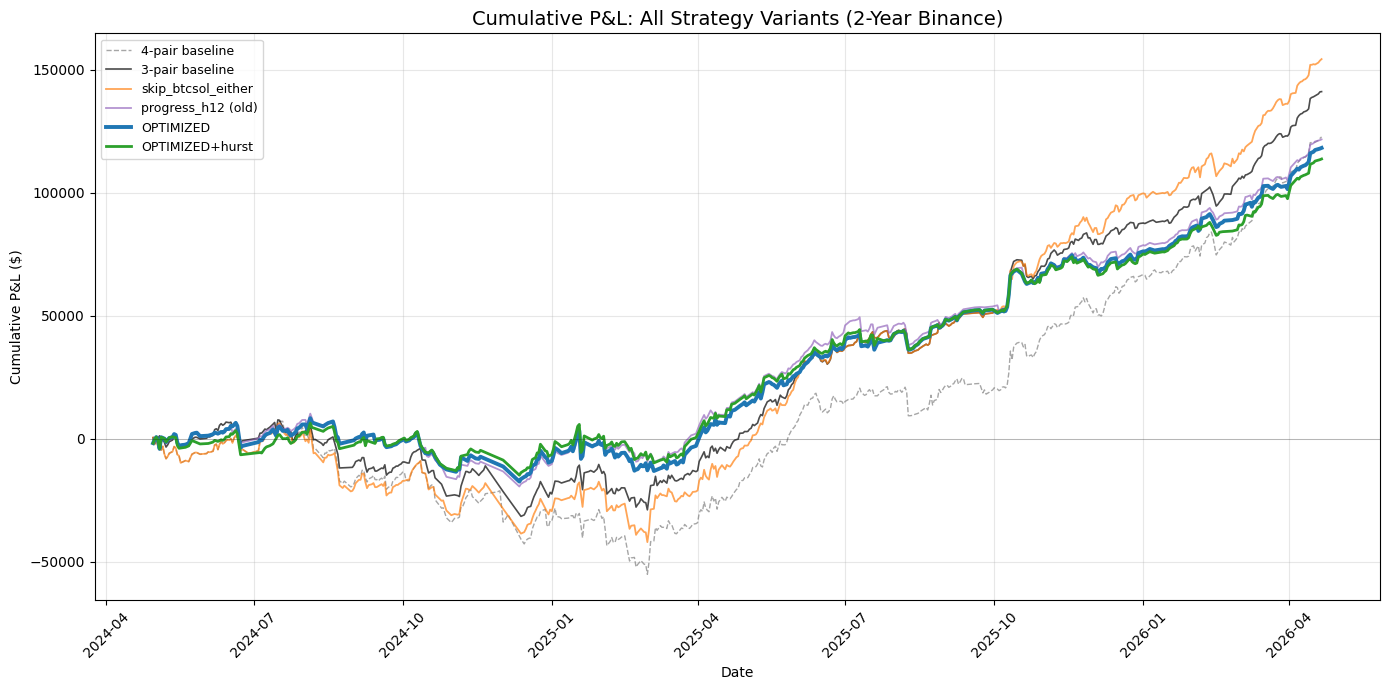


Final cumulative P&L:
  4-pair baseline          : $  +122,658  (Max DD: $62,207)
  3-pair baseline          : $  +141,069  (Max DD: $39,221)
  skip_btcsol_either       : $  +154,291  (Max DD: $48,384)
  progress_h12 (old)       : $  +121,643  (Max DD: $29,637)
  OPTIMIZED                : $  +118,183  (Max DD: $25,781)
  OPTIMIZED+hurst          : $  +113,685  (Max DD: $21,167)


In [19]:
# Equity curves: all variants on the same chart
import matplotlib.dates as mdates


def variant_daily_equity(trades):
    df = pd.DataFrame([
        {'exit_dt': pd.to_datetime(t.exit_ts, unit='ms', utc=True), 'net_pnl': t.net_pnl}
        for t in trades
    ])
    if df.empty:
        return pd.DataFrame(columns=['date', 'daily_pnl', 'cumulative_pnl'])
    daily = df.groupby(df['exit_dt'].dt.date)['net_pnl'].sum().reset_index()
    daily.columns = ['date', 'daily_pnl']
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.sort_values('date')
    daily['cumulative_pnl'] = daily['daily_pnl'].cumsum()
    return daily

fig, ax = plt.subplots(figsize=(14, 7))

plot_variants = {
    '4-pair baseline': (baseline_4pair_trades, 'gray', 1.0, '--'),
    '3-pair baseline': (baseline_3pair_trades, 'black', 1.2, '-'),
    'skip_btcsol_either': (scenario_variants['skip_btcsol_either'], 'tab:orange', 1.3, '-'),
    'progress_h12 (old)': (progress_variants['progress_h12_i10_z2.5'], 'tab:purple', 1.3, '-'),
    'OPTIMIZED': (optimized_trades, 'tab:blue', 2.8, '-'),
    'OPTIMIZED+hurst': (optimized_hurst_trades, 'tab:green', 2.0, '-'),
}

for name, (trades, color, lw, ls) in plot_variants.items():
    eq = variant_daily_equity(trades)
    if eq.empty:
        continue
    ax.plot(eq['date'], eq['cumulative_pnl'], label=name,
            color=color, linewidth=lw, linestyle=ls,
            alpha=1.0 if 'OPTIMIZED' in name else 0.7)

ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.set_title('Cumulative P&L: All Strategy Variants (2-Year Binance)', fontsize=14)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print final P&L for each
print('\nFinal cumulative P&L:')
for name, (trades, _, _, _) in plot_variants.items():
    eq = variant_daily_equity(trades)
    if eq.empty:
        continue
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    print(f'  {name:25s}: ${eq["cumulative_pnl"].iloc[-1]:+10,.0f}  (Max DD: ${dd.max():,.0f})')

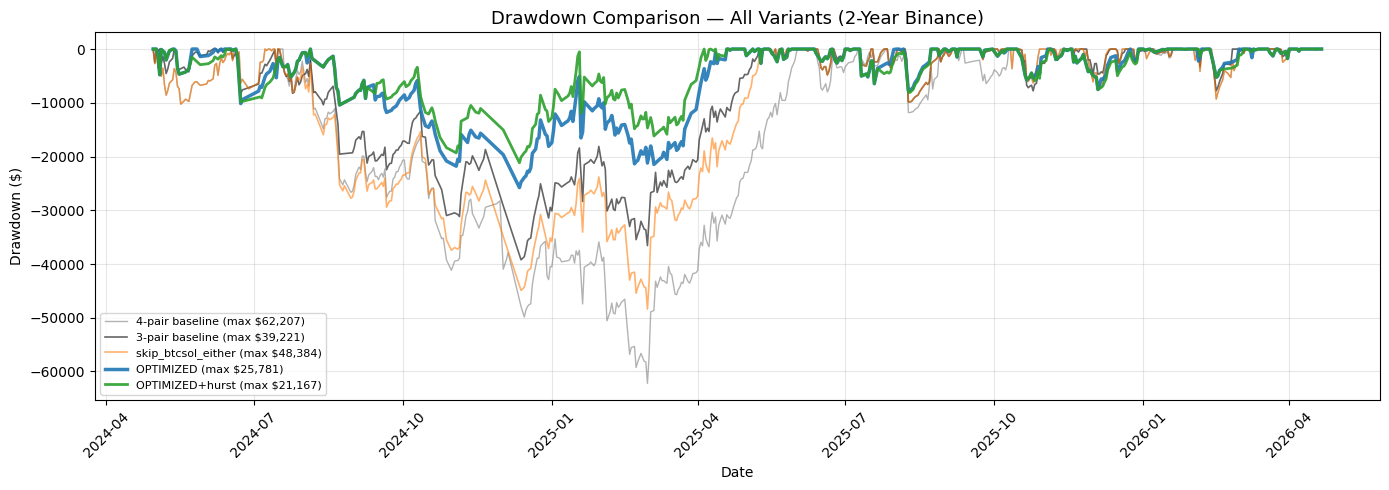

In [20]:
# Drawdown comparison
fig, ax = plt.subplots(figsize=(14, 5))

dd_variants = {
    '4-pair baseline': (baseline_4pair_trades, 'gray', 1.0),
    '3-pair baseline': (baseline_3pair_trades, 'black', 1.2),
    'skip_btcsol_either': (scenario_variants['skip_btcsol_either'], 'tab:orange', 1.2),
    'OPTIMIZED': (optimized_trades, 'tab:blue', 2.5),
    'OPTIMIZED+hurst': (optimized_hurst_trades, 'tab:green', 2.0),
}

for name, (trades, color, lw) in dd_variants.items():
    eq = variant_daily_equity(trades)
    if eq.empty:
        continue
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    ax.plot(eq['date'], -dd, label=f'{name} (max ${dd.max():,.0f})',
            color=color, linewidth=lw, alpha=0.9 if 'OPTIMIZED' in name else 0.6)

ax.set_title('Drawdown Comparison — All Variants (2-Year Binance)', fontsize=13)
ax.set_ylabel('Drawdown ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Monthly P&L breakdown for the optimized strategy
opt_summary = summarize_backtest(optimized_trades, scenario_prices)
print('=== OPTIMIZED Strategy — Monthly Breakdown (2-Year Binance) ===\n')
print(f'{"Month":<10} {"Trades":>6} {"WR":>5} {"Net":>10} {"$/day":>7} {"Max DD":>9}')
print('-' * 55)
for m in opt_summary.monthly:
    print(f'{m["month"]:<10} {m["trades"]:>6} {m["win_rate"]:>4.0f}% {m["net"]:>+10,.0f} {m["net_per_day"]:>7,.0f} {m["max_dd"]:>9,.0f}')

print(f'\n{"TOTAL":<10} {len(optimized_trades):>6} {opt_summary.win_rate:>4.0f}% {opt_summary.total_net:>+10,.0f} {"":>7} {opt_summary.max_drawdown:>9,.0f}')
print(f'Sharpe: {opt_summary.sharpe:.2f}')

=== OPTIMIZED Strategy — Monthly Breakdown (2-Year Binance) ===

Month      Trades    WR        Net   $/day    Max DD
-------------------------------------------------------
2024-04         1    0%     -1,840  -1,227     1,840
2024-05        29   59%     +2,854     102     6,303
2024-06        24   67%     -3,997    -322     9,736
2024-07        35   66%     +8,730     331     3,479
2024-08        24   46%     -7,843    -408     7,843
2024-09        34   62%       +907      32     6,120
2024-10        25   52%    -11,330    -490    13,514
2024-11        15   60%     +5,170     472     2,255
2024-12        21   57%     -2,442     -83     7,174
2025-01        31   74%     +7,484     242    12,241
2025-02        41   56%     -7,666    -277     9,864
2025-03        32   66%     +7,024     222     5,461
2025-04        36   81%    +17,728     687     2,815
2025-05        36   67%    +10,864     419     2,966
2025-06        37   73%    +11,429     402     1,743
2025-07        36   69%     +5,

## Export results

In [22]:
# Save the concurrent unrealized time series
out_path = REPORTS_DIR / 'concurrent_unrealized.csv'
conc_filt.to_csv(out_path, index=False)
print(f'Saved filtered concurrent unrealized to {out_path}')

out_path_uf = REPORTS_DIR / 'concurrent_unrealized_unfiltered.csv'
conc.to_csv(out_path_uf, index=False)
print(f'Saved unfiltered concurrent unrealized to {out_path_uf}')

Saved filtered concurrent unrealized to /Users/thomas/My_Projects/metaverse/hypemm/data/runs/backtest/original_4pair_2y/concurrent_unrealized.csv
Saved unfiltered concurrent unrealized to /Users/thomas/My_Projects/metaverse/hypemm/data/runs/backtest/original_4pair_2y/concurrent_unrealized_unfiltered.csv
